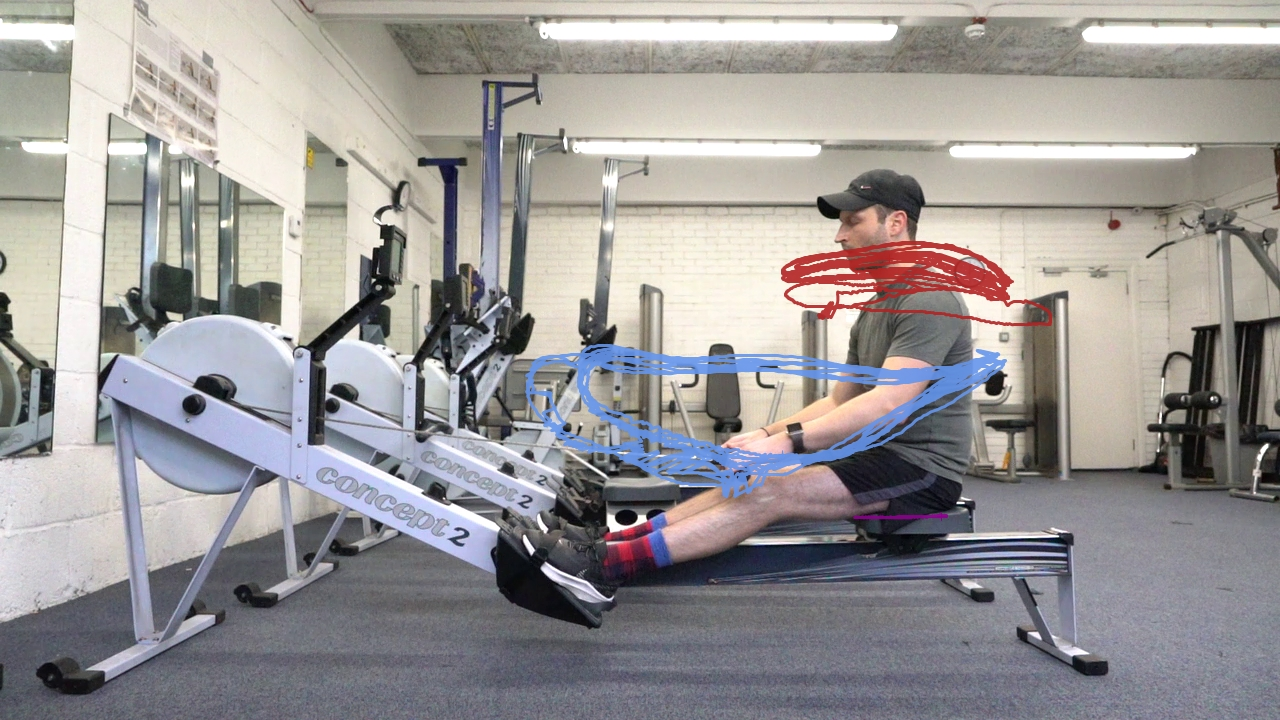

In [32]:
from IPython.display import Image
Image(filename='/Users/szabolcs/Documents/Documents - Szabolcs’s MacBook Pro/Rowing/Data Analysis/Szabi/2023.12.27.Szabi_20strokePerMinute_tracking.jpg') 

In [33]:
import sys
print(sys.executable)
# install into the kernel
# python -m pip install pandas
# python -m pip install -U matplotlib
# python -m pip install scipy
# python -m pip install seaborn

/Users/szabolcs/Documents/Documents - Szabolcs’s MacBook Pro/Rowing/Data Analysis/.venv/bin/python


In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Set a clean, readable theme for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

df = pd.read_csv('Szabi/2023.12.27.Szabi_20strokesPerMinute_trajectory.csv')
df = df.rename(columns={'Handle/0/X':'Handle_X', 'Handle/0/Y':'Handle_Y', 'Shoulder/0/X':'Shoulder_X', 'Shoulder/0/Y':'Shoulder_Y', 'Seat/0/X':'Seat_X', 'Seat/0/Y':'Seat_Y'})
df = df.drop(columns=['Time'])
df.insert(0, 'Index', range(0, len(df)))
df = df.set_index('Index')
# df.head()

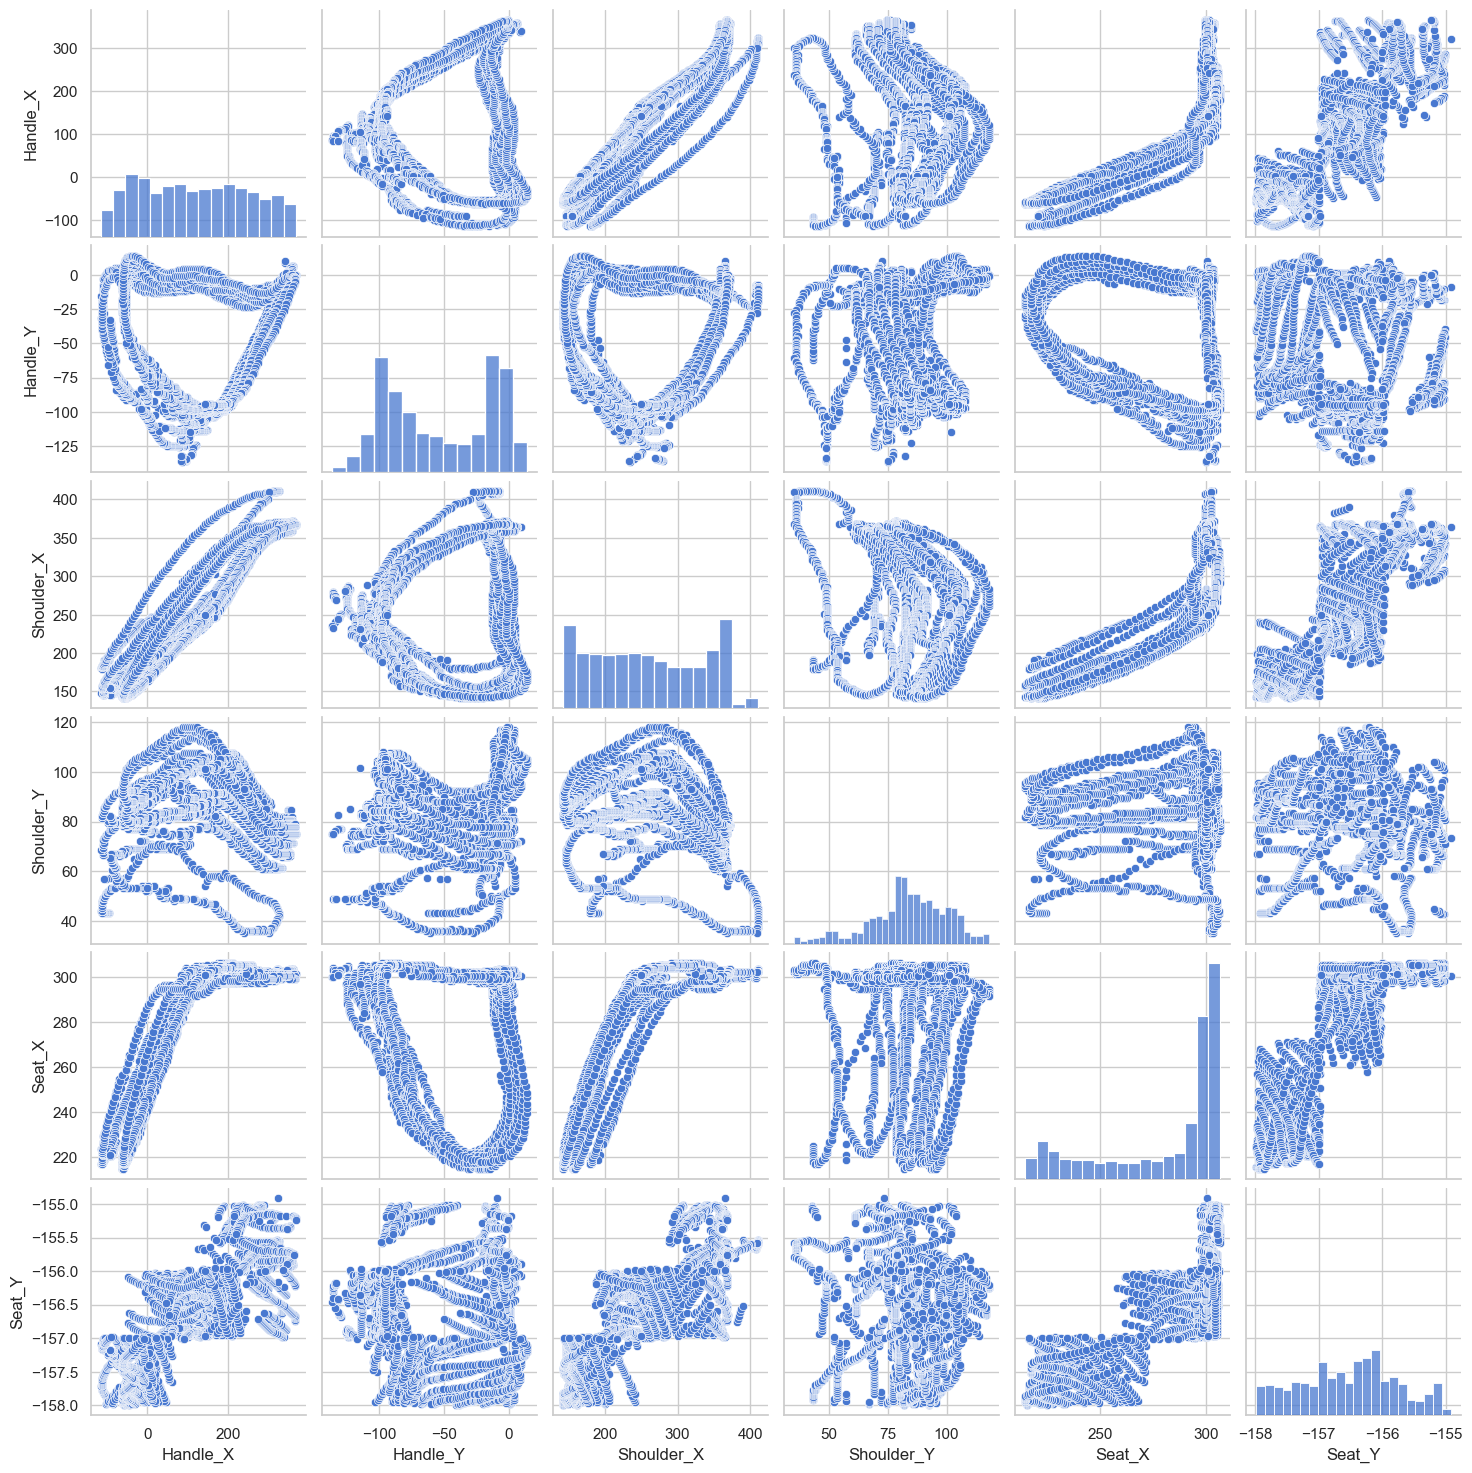

In [35]:
sns.pairplot(df)
plt.show()

In [36]:
# smoothing the data
df['Handle_X_Smooth'] = df['Handle_X'].rolling(10).mean()
df['Handle_Y_Smooth'] = df['Handle_Y'].rolling(10).mean()
df['Shoulder_X_Smooth'] = df['Shoulder_X'].rolling(10).mean()
df['Shoulder_Y_Smooth'] = df['Shoulder_Y'].rolling(10).mean()
df['Seat_X_Smooth'] = df['Seat_X'].rolling(10).mean()
df['Seat_Y_Smooth'] = df['Seat_Y'].rolling(10).mean()

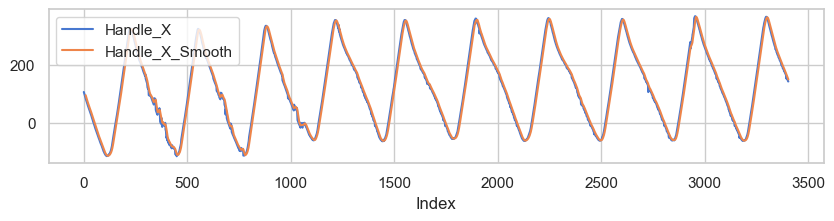

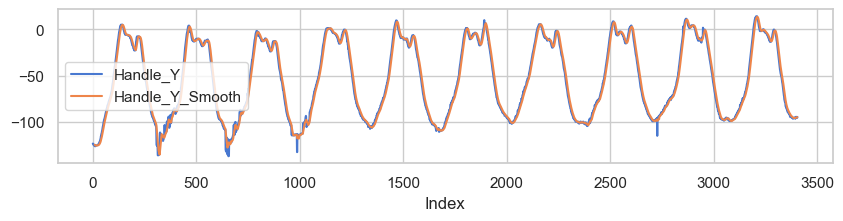

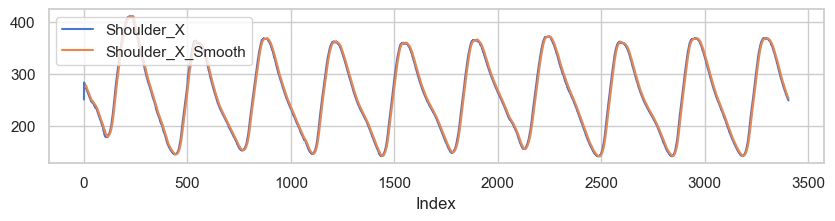

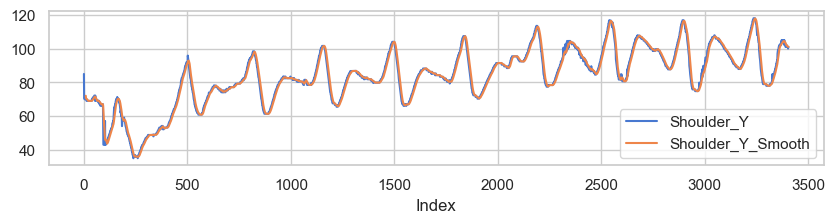

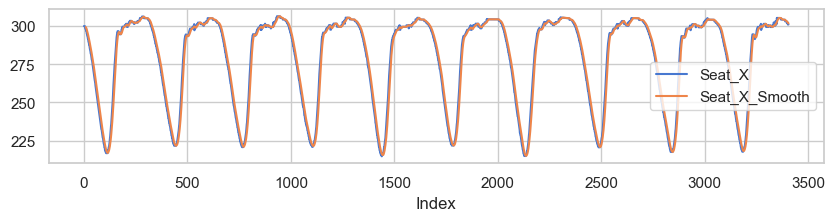

In [37]:
df.plot(y=['Handle_X', 'Handle_X_Smooth'], figsize=(10, 2))
df.plot(y=['Handle_Y', 'Handle_Y_Smooth'], figsize=(10, 2))
df.plot(y=['Shoulder_X', 'Shoulder_X_Smooth'], figsize=(10, 2))
df.plot(y=['Shoulder_Y', 'Shoulder_Y_Smooth'], figsize=(10, 2))
df.plot(y=['Seat_X', 'Seat_X_Smooth'], figsize=(10, 2))
plt.show()

In [38]:
def debugStrokeStart(window):
    current = window.iloc[1]
    currentIndex = window.index[1]
    prev = window.iloc[0]
    prevIndex = window.index[0]

    if currentIndex > 950 and currentIndex < 1010:
        print(window)
    
    if prev > 100 and current <= 100:
        return 100
    else:
        return 0

def markStrokeStart(window):
    current = window[1]
    prev = window[0]
    
    if prev > 100 and current <= 100:
        return 100
    else:
        return 0

# mark when handle is roughly at straight hands, hands away as this is the point where the stroke cycle starts
# df['Handle_X_Smooth'].rolling(2).apply(debugStrokeStart)
df['Stroke_Start'] = df['Handle_X_Smooth'].rolling(2).apply(markStrokeStart, raw=True)

In [39]:
# remove partial stroke cycles
stroke_starts = df.loc[df['Stroke_Start'] == 100]
print(stroke_starts.index)
first_index = stroke_starts.index[0]
last_index = stroke_starts.index[-1] - 3 # delete before new cycle starts
df = df.drop(df.index[0:first_index])
df = df.drop(df.index[last_index:df.index[-1]])

Index([321, 655, 989, 1359, 1695, 2046, 2393, 2750, 3094], dtype='int64', name='Index')


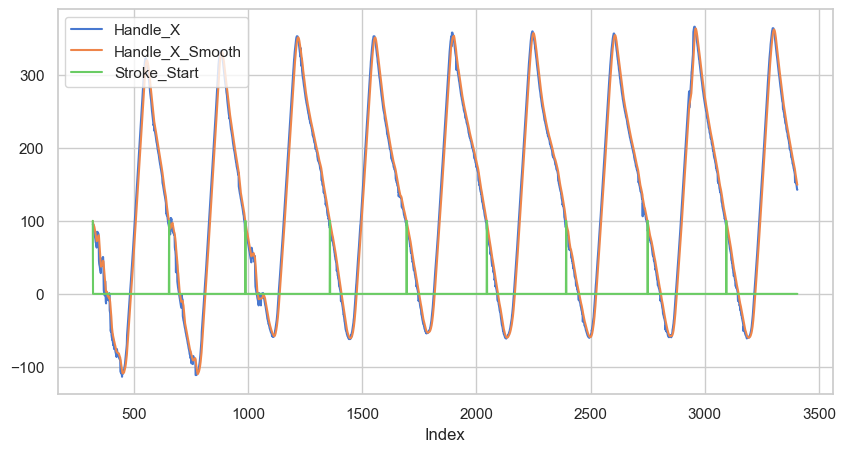

In [40]:
df.plot(y=['Handle_X', 'Handle_X_Smooth', 'Stroke_Start'], figsize=(10, 5))
plt.show()

In [41]:
df = df.drop(columns=['Handle_X', 'Handle_Y', 'Shoulder_X', 'Shoulder_Y', 'Seat_X', 'Seat_Y'])

In [42]:
# split into cycles
start_index = stroke_starts.index[0]
cycles = []
for index in stroke_starts.index[1:]:
    cycle = df[start_index:index-1]
    cycles.append(cycle)
    start_index = index

for c in cycles:
  print(c.shape)

(333, 7)
(333, 7)
(369, 7)
(335, 7)
(350, 7)
(346, 7)
(356, 7)
(335, 7)


In [43]:
# add new index to make merge easier
for c in cycles:
    c.reset_index(drop=True, inplace=True)
    c.index.name = 'Cycle_Index'

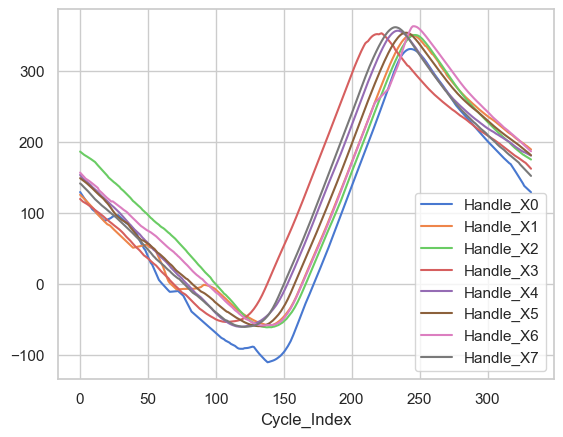

In [44]:
# verify the split was okay and the lines are roughly together
df_handles = pd.DataFrame()
for index, c in enumerate(cycles):
    df_handles['Handle_X' + str(index)] = c['Handle_X_Smooth']
df_handles.plot()
plt.show()

In [45]:
# merge the cycles into one average dataframe
df_avg = pd.concat(cycles).groupby('Cycle_Index', as_index=True).mean()

# drop Stroke_Start as it is not needed anymore
df_avg = df_avg.drop(columns=['Stroke_Start'])

In [46]:
# remove rows that are longer than minimum length, as the average value cannot be calculated properly and skews the data anyway
rows = []
for c in cycles:
    rows.append(c.shape[0])
shortest_row_count = min(rows)
print(shortest_row_count)
df_avg = df_avg[0:shortest_row_count]

333


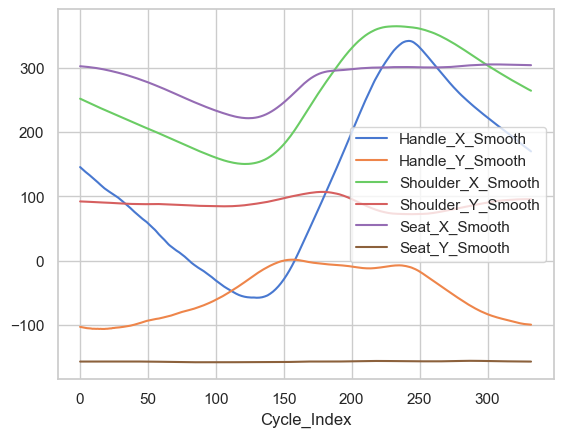

In [47]:
df_avg.plot()
plt.show()

In [48]:
# standardize, rescale the values
import scipy
from scipy import stats

df_avg['Handle_X_Smooth'] = stats.zscore(df_avg['Handle_X_Smooth'])
df_avg['Handle_Y_Smooth'] = stats.zscore(df_avg['Handle_Y_Smooth'])
df_avg['Shoulder_X_Smooth'] = stats.zscore(df_avg['Shoulder_X_Smooth'])
df_avg['Shoulder_Y_Smooth'] = stats.zscore(df_avg['Shoulder_Y_Smooth'])
df_avg['Seat_X_Smooth'] = stats.zscore(df_avg['Seat_X_Smooth'])

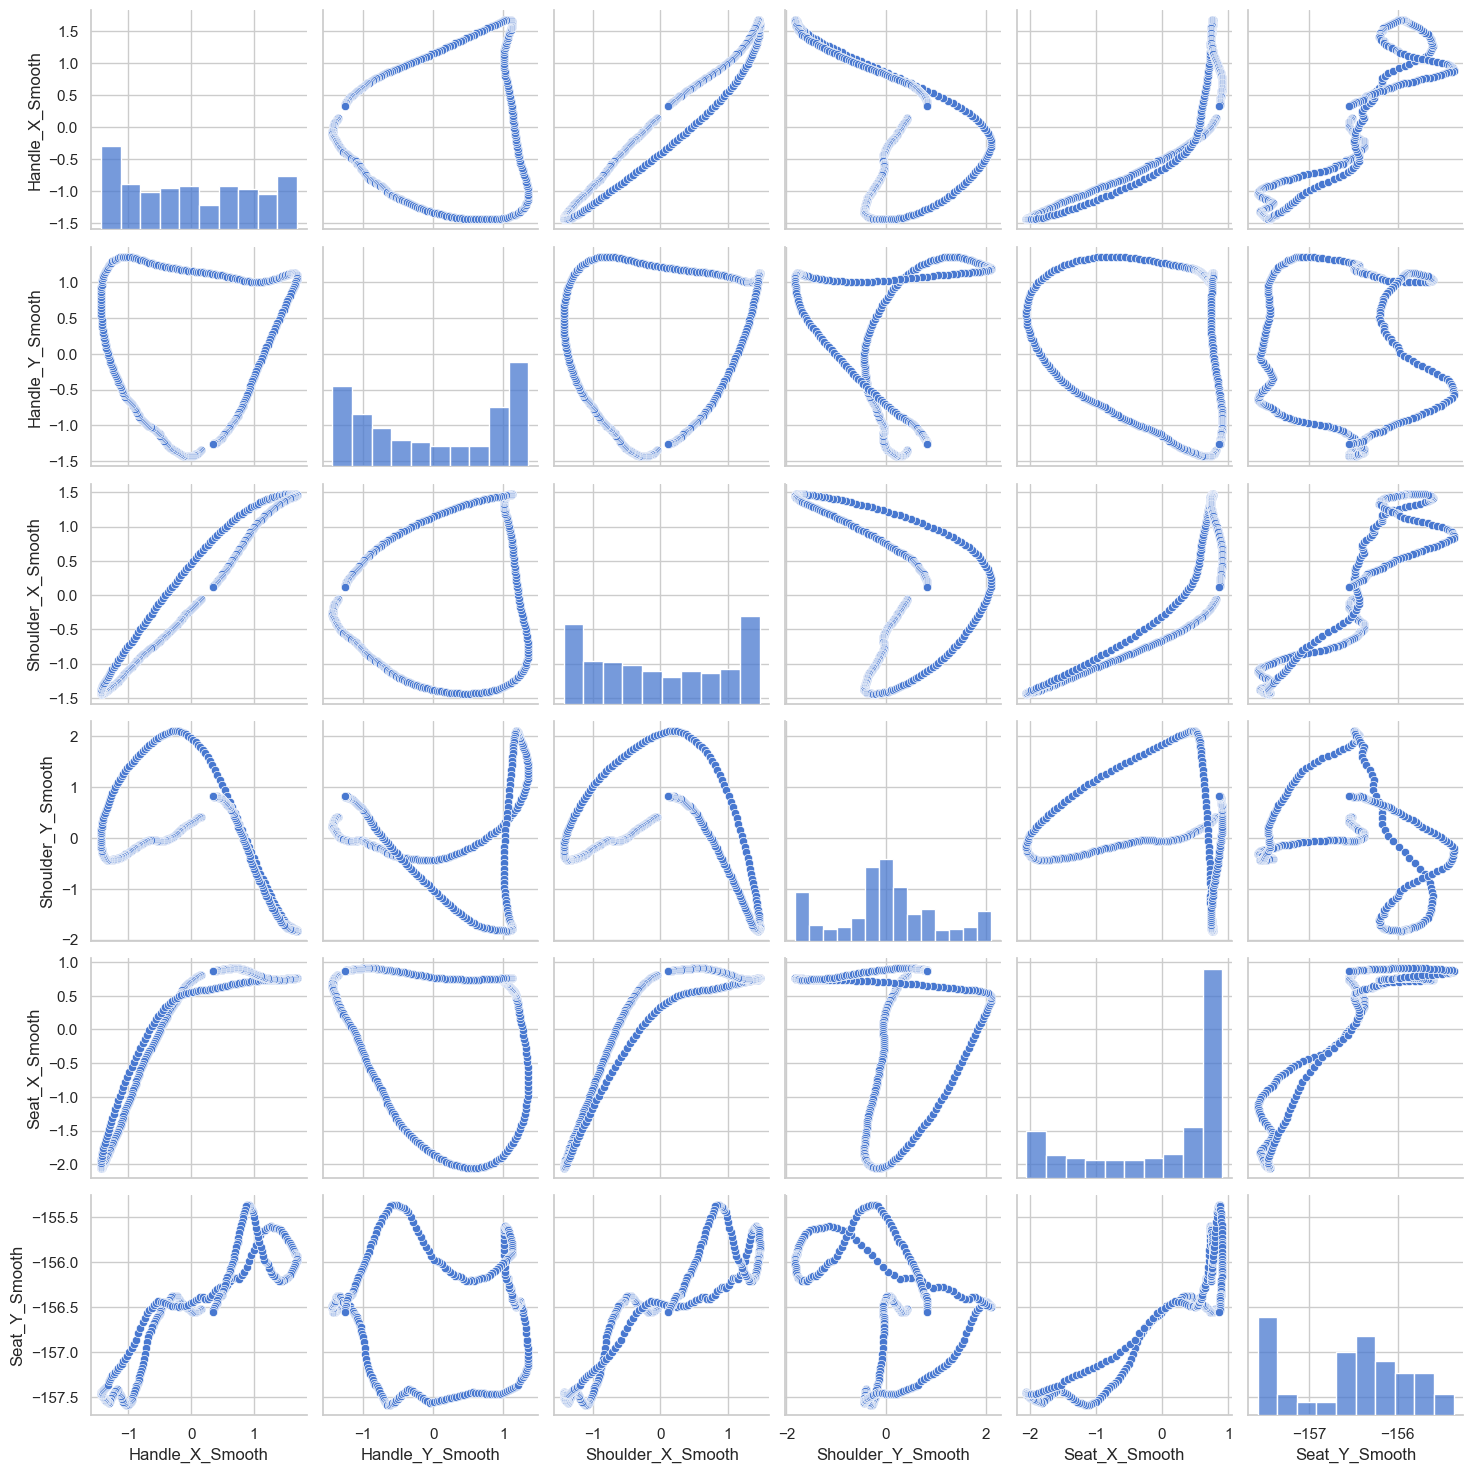

In [49]:
sns.pairplot(df_avg)
plt.show()

In [50]:
catch_index = 125
finish_index = 240

def plot(title, data):
    ax = data.plot(figsize=(10, 5))
    ax.axvline(catch_index, color='green', linestyle='dashed')
    plt.text(catch_index + 2, 1.5, 'Catch', rotation=90)
    ax.axvline(finish_index, color='green', linestyle='dashed')
    plt.text(finish_index + 2, -2, 'Finish', rotation=90)
    
    plt.title(title, color = 'black')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.show()

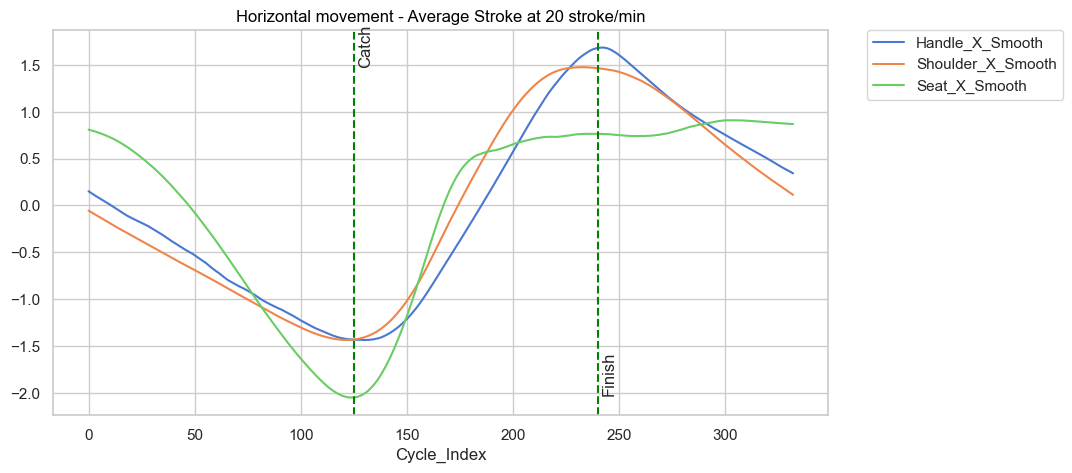

In [51]:
plot('Horizontal movement - Average Stroke at 20 stroke/min', df_avg[['Handle_X_Smooth', 'Shoulder_X_Smooth', 'Seat_X_Smooth']])

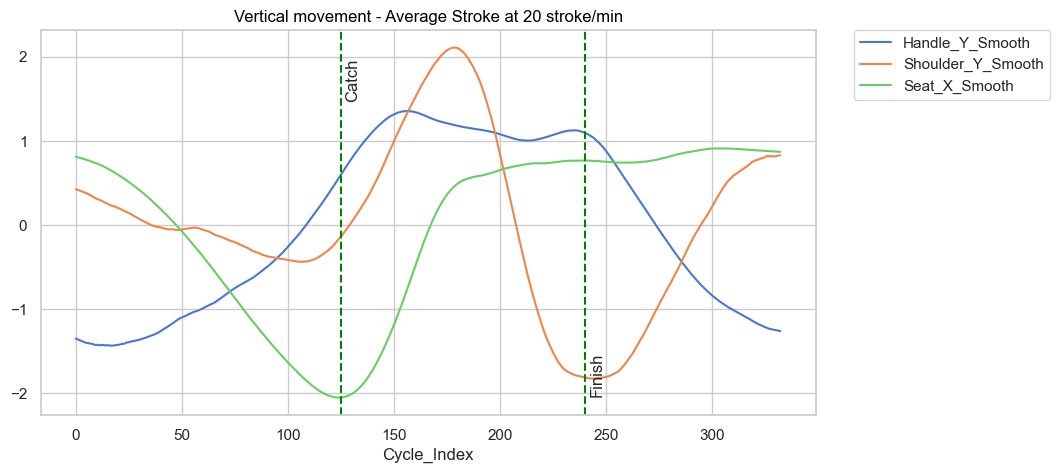

In [52]:
plot('Vertical movement - Average Stroke at 20 stroke/min', df_avg[['Handle_Y_Smooth', 'Shoulder_Y_Smooth', 'Seat_X_Smooth']])

In [53]:
# stroke ratio
drive_duration = finish_index - catch_index
recovery_duration = shortest_row_count - drive_duration
drive_percentage = (drive_duration / shortest_row_count) * 100
recovery_percentage = (recovery_duration / shortest_row_count) * 100
print(f'Averaged Drive / Recovery Ratio: {drive_percentage:2.0f} to {recovery_percentage:2.0f}')
print(f'   Ideal Drive / Recovery Ratio: 33 to 66')

Averaged Drive / Recovery Ratio: 35 to 65
   Ideal Drive / Recovery Ratio: 33 to 66


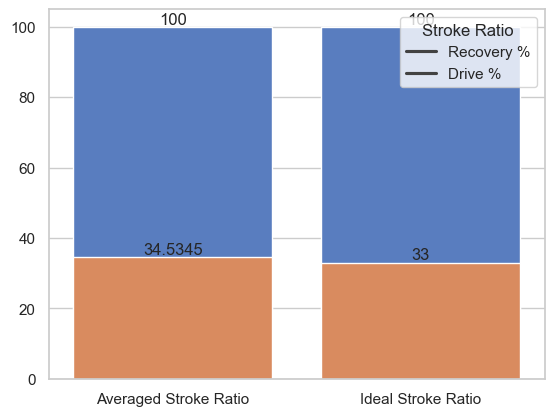

In [54]:
sns.barplot(data=[100, 100])
bar = sns.barplot(data=[drive_percentage, 33])
bar.set_xticks(range(2))
bar.set_xticklabels(['Averaged Stroke Ratio', 'Ideal Stroke Ratio'])
for i in bar.containers:
    bar.bar_label(i,)
plt.legend(title='Stroke Ratio', loc='upper right', labels=['Recovery %', 'Drive %'], facecolor='w')
plt.show()

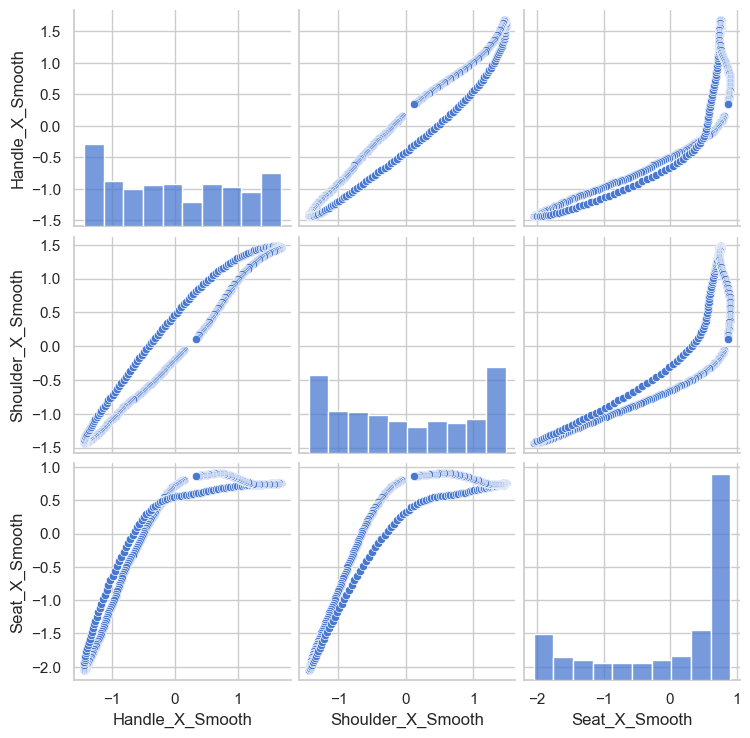

In [55]:
# correlation during stroke
sns.pairplot(df_avg[['Handle_X_Smooth', 'Shoulder_X_Smooth', 'Seat_X_Smooth']])
plt.show()

In [56]:
# Derivatives
# Caveat - smoothing pushes right the line potentially which gives misaligned lines
def derivate(column_name, derivative_column_name, smoothing, scaling):
    dy = np.diff(df_avg[column_name])
    dx = np.diff(df_avg.index)
    deriv = dy / dx
    # prepanding first element so the new data has the same dimension as the original
    df_avg[derivative_column_name] = np.insert(deriv, 0, deriv[0], axis=0)
    # smoothing the derivative
    df_avg[derivative_column_name] = df_avg[derivative_column_name].rolling(smoothing).mean()
    # back fill NaN so rescaling will work
    df_avg[derivative_column_name] = df_avg[derivative_column_name].bfill()
    # rescale the derivative
    df_avg[derivative_column_name] = stats.zscore(df_avg[derivative_column_name]) * scaling

In [57]:
derivate('Handle_X_Smooth', 'Handle_X_Velocity', 60, 1)
derivate('Handle_X_Velocity', 'Handle_X_Acceleration', 30, 0.5)
derivate('Handle_X_Acceleration', 'Handle_X_Jerk', 20, 0.2)

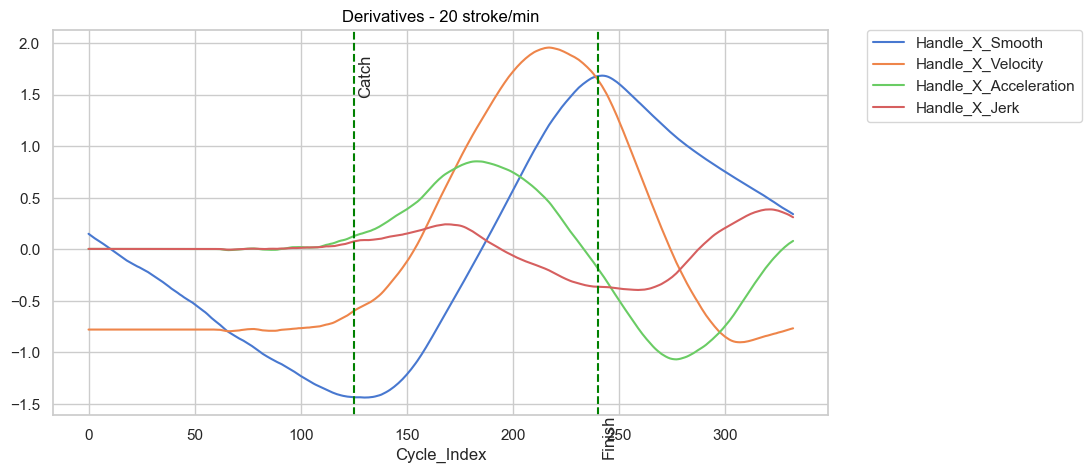

In [58]:
plot('Derivatives - 20 stroke/min', df_avg[['Handle_X_Smooth', 'Handle_X_Velocity', 'Handle_X_Acceleration', 'Handle_X_Jerk']])

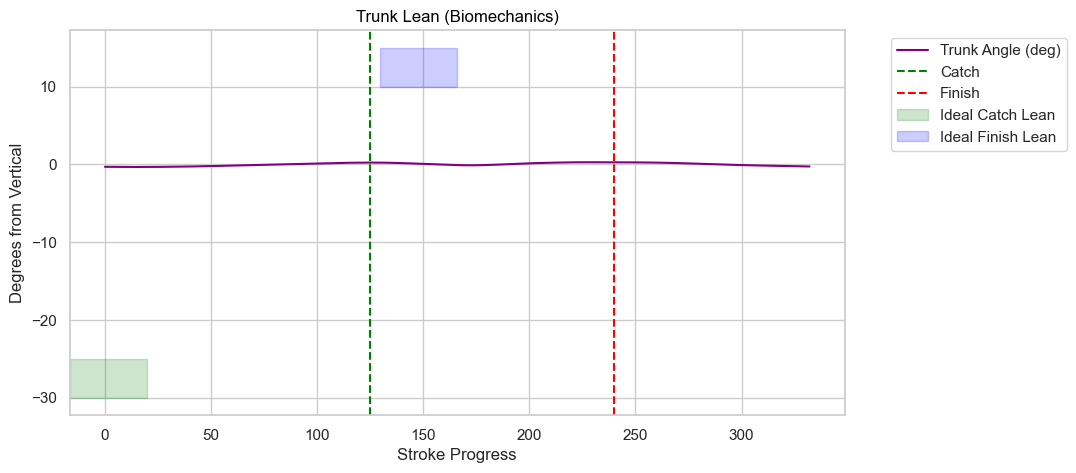

Trunk Lean at Catch: 0.2° (Goal: -30° to -25°)
Trunk Lean at Finish: 0.3° (Goal: 10° to 15°)
Total Trunk Range: 0.0° (Goal: 35° to 45°)


In [59]:
# Biomechanics: Trunk Angle Calculation
# Assuming X is horizontal and Y is vertical. 
# Angle relative to vertical (0 deg = upright)
def calc_trunk_angle(row):
    dx = row['Shoulder_X_Smooth'] - row['Seat_X_Smooth']
    dy = row['Shoulder_Y_Smooth'] - row['Seat_Y_Smooth']
    return np.degrees(np.arctan2(dx, dy))

df_avg['Trunk_Angle'] = df_avg.apply(calc_trunk_angle, axis=1)

# Visualization of Trunk Lean
plt.figure(figsize=(10, 5))
plt.plot(df_avg.index, df_avg['Trunk_Angle'], label='Trunk Angle (deg)', color='purple')
plt.axvline(catch_index, color='green', linestyle='--', label='Catch')
plt.axvline(finish_index, color='red', linestyle='--', label='Finish')

# Adding Ideal Goal Zones
plt.axhspan(-30, -25, xmin=0.0, xmax=0.1, alpha=0.2, color='green', label='Ideal Catch Lean')
plt.axhspan(10, 15, xmin=0.4, xmax=0.5, alpha=0.2, color='blue', label='Ideal Finish Lean')

plt.title('Trunk Lean (Biomechanics)', color='black')
plt.ylabel('Degrees from Vertical')
plt.xlabel('Stroke Progress')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

print(f"Trunk Lean at Catch: {df_avg.loc[catch_index, 'Trunk_Angle']:.1f}° (Goal: -30° to -25°)")
print(f"Trunk Lean at Finish: {df_avg.loc[finish_index, 'Trunk_Angle']:.1f}° (Goal: 10° to 15°)")
print(f"Total Trunk Range: {abs(df_avg.loc[finish_index, 'Trunk_Angle'] - df_avg.loc[catch_index, 'Trunk_Angle']):.1f}° (Goal: 35° to 45°)")


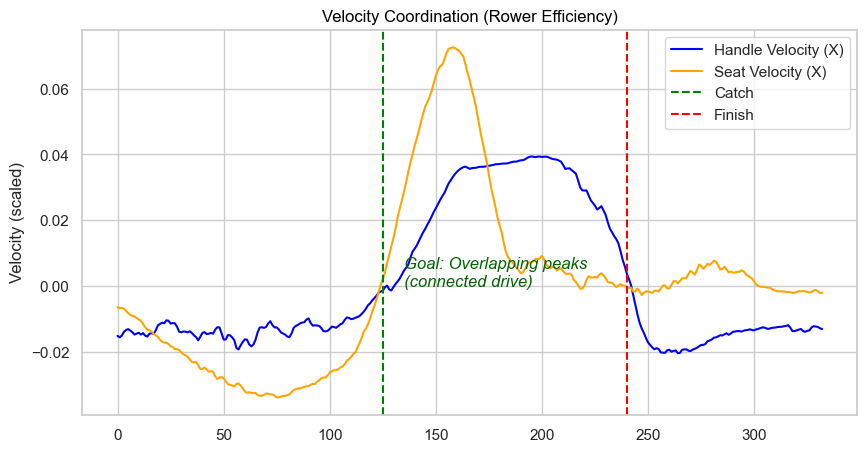

In [60]:
# Coordination: Seat vs Handle Velocity
df_avg['Handle_X_Vel'] = np.gradient(df_avg['Handle_X_Smooth'])
df_avg['Seat_X_Vel'] = np.gradient(df_avg['Seat_X_Smooth'])

plt.figure(figsize=(10, 5))
plt.plot(df_avg.index, df_avg['Handle_X_Vel'], label='Handle Velocity (X)', color='blue')
plt.plot(df_avg.index, df_avg['Seat_X_Vel'], label='Seat Velocity (X)', color='orange')
plt.axvline(catch_index, color='green', linestyle='--', label='Catch')
plt.axvline(finish_index, color='red', linestyle='--', label='Finish')
plt.title('Velocity Coordination (Rower Efficiency)', color='black')
plt.ylabel('Velocity (scaled)')
plt.text(catch_index + 10, 0, 'Goal: Overlapping peaks\n(connected drive)', color='darkgreen', style='italic')
plt.legend()
plt.grid(True)
plt.show()


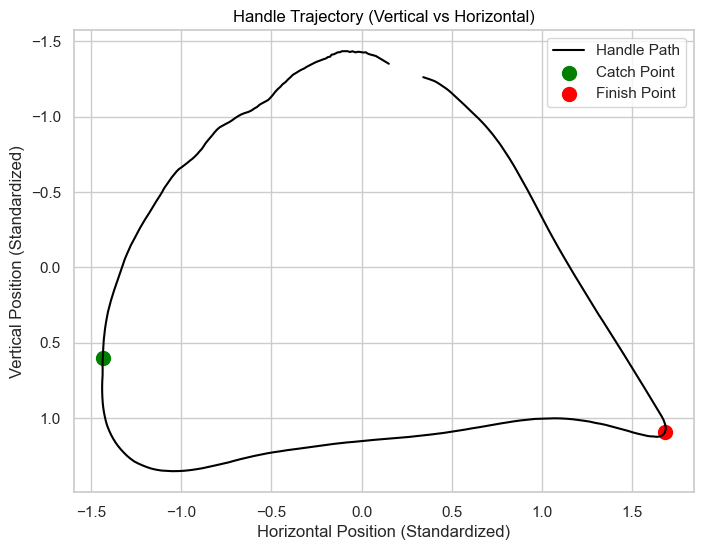

In [61]:
# Handle Trajectory (Box Plot)
plt.figure(figsize=(8, 6))
plt.plot(df_avg['Handle_X_Smooth'], df_avg['Handle_Y_Smooth'], label='Handle Path', color='black')
plt.scatter(df_avg.loc[catch_index, 'Handle_X_Smooth'], df_avg.loc[catch_index, 'Handle_Y_Smooth'], color='green', s=100, label='Catch Point')
plt.scatter(df_avg.loc[finish_index, 'Handle_X_Smooth'], df_avg.loc[finish_index, 'Handle_Y_Smooth'], color='red', s=100, label='Finish Point')
plt.title('Handle Trajectory (Vertical vs Horizontal)', color='black')
plt.xlabel('Horizontal Position (Standardized)')
plt.ylabel('Vertical Position (Standardized)')
plt.legend()
plt.gca().invert_yaxis() 
plt.grid(True)
plt.show()


In [62]:
# Consistency Statistics
stroke_lengths = [c['Seat_X_Smooth'].max() - c['Seat_X_Smooth'].min() for c in cycles]
stroke_durations = [len(c) for c in cycles]

print(f"--- Consistency Analysis ---")
print(f"Mean Stroke Length: {np.mean(stroke_lengths):.2f} px (±{np.std(stroke_lengths):.2f})")
print(f"Mean Stroke Duration: {np.mean(stroke_durations):.2f} frames (±{np.std(stroke_durations):.2f})")
print(f"Variability (CV Length): {(np.std(stroke_lengths)/np.mean(stroke_lengths))*100:.2f}% (Goal: < 2%)")

--- Consistency Analysis ---
Mean Stroke Length: 86.35 px (±2.59)
Mean Stroke Duration: 344.62 frames (±12.30)
Variability (CV Length): 3.00% (Goal: < 2%)
